In [3]:
# Módulos importados

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


numeric_data_directory = os.path.dirname('dados_brutos/')


# dimensões fixas (largura e altura)
b = 30 #mm
h = 25 #mm

# Propriedades do material (módulo de Young, coeficiente de Poisson)
E = 200e9 # GPa - para aço
v = 0.3   # para aço

# Carga aplicada
q = 0.5e6 # Pa - N/m²

# Valores necessários para cálculo da solução analítica

p = q * b # 0,015 MN/m = 15 MPa.mm (não é o que está no apêndice!)
I = (b * (h**3))/12 # 39.062,5 mm⁴ - momento de inércia da seção transversal da viga 

# Funções base para o código

def obtain_x_axis_array(L:int, size = 51): # size tem que ser do mesmo tamanho do dataframe; L é comprimento em mm

    return np.linspace(0, L, size)


def calculate_analytic_solution(x_axis): # x_axis precisa ser linspace!

    
    return ((-p/(E*I))*(x_axis**2)*(((x_axis**2)/24) - ((x_axis*(x_axis[-1]))/6) + (((x_axis[-1])**2)/4)))


def plot_deformation_graphic(_numeric_data, _x_axis, _y_axis): # numeric_data precisa ser dataframe, x_axis e y_axis precisam ser array numpy

    if len(_y_axis) == len(_numeric_data['y']):
        plt.figsize = (3,2)
        plt.tight_layout()
        max_num = _numeric_data['y'].iloc[-1]
        max_ana = _y_axis.take(-1)
        error_pct = (abs(max_num) - abs(max_ana))*100/abs(max_ana)  
        plt.plot(_numeric_data['x'], _numeric_data['y'], label = 'Resultado numérico ' + '($u_{y_{max}}$' + f' = { max_num})')
        plt.plot(_x_axis, _y_axis, label = 'solução analítica da viga 1D ' +  '($u_{y_{max}}$' + f' = {max_ana})')
        plt.title(f'Deformada da fibra média para viga de {int(_x_axis[-1])}mm')
        plt.xlabel('Posição ($z$) em mm')
        plt.ylabel('Deslocamento no eixo y ($u_y$) em mm')
        plt.legend()
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5, edgecolor='gray')
        ax = plt.gca()
        plt.text(0.96, 0.84, ("Diferença relativa de $u_{y_{max}}$ entre\nresultados numérico e analítico: " + f" {error_pct:.2f} %"),
        transform = ax.transAxes,
        fontsize=10,
        verticalalignment='bottom', 
        horizontalalignment='right', 
        bbox=props)
        plt.show()

    else:
        raise ValueError('Número de elementos do eixo y fornecido não batem com o número de linhas dos dados brutos fornecidos!')
    

def calculate_sigma_zz_max(L):

    return p*(((L**2)*h)/(4*I))

def calculate_relative_error(val1, val2, percentual = True):
    if percentual:
        multiplier = 100
    else:
        multiplier = 1

    return abs(((multiplier*((val1) - val2)))/val2)

# Gráfico para viga de 60mm

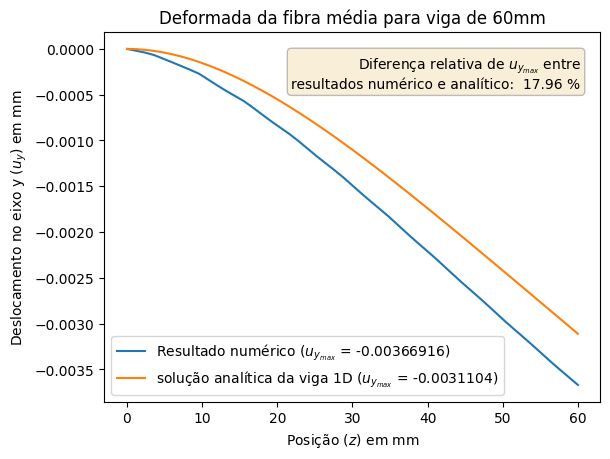

In [4]:
numeric_data = pd.read_csv(os.path.join(numeric_data_directory, 'deformada_fibra_media_60mm_final.csv'), sep = ';')

x_analytic_solution_1d = obtain_x_axis_array(60, size = len(numeric_data['x'])) # para 60mm
y_analytic_solution_1d = calculate_analytic_solution(x_analytic_solution_1d)

plot_deformation_graphic(numeric_data, x_analytic_solution_1d, y_analytic_solution_1d)

# Gráfico para viga de 100mm

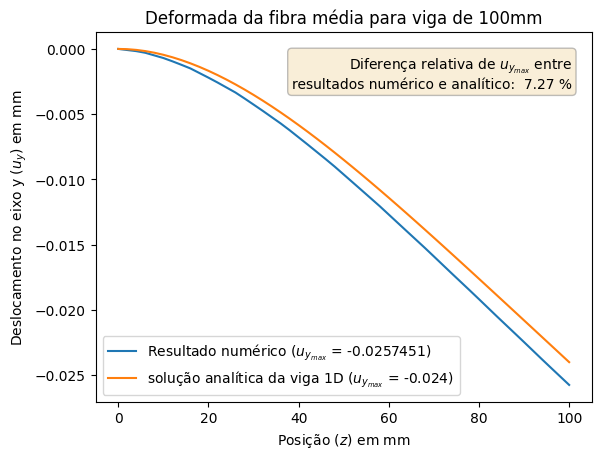

In [5]:
numeric_data = pd.read_csv(os.path.join(numeric_data_directory, 'deformada_fibra_media_100mm_final.csv'), sep = ';')

x_analytic_solution_1d = obtain_x_axis_array(100, size = len(numeric_data['x'])) # para 100mm
y_analytic_solution_1d = calculate_analytic_solution(x_analytic_solution_1d)
# print((-p*(100**4))/(8*E*I) == y_analytic_solution_1d[-1]) # Verificar se $u_max$ representa o último elemento da solução analítica

plot_deformation_graphic(numeric_data, x_analytic_solution_1d, y_analytic_solution_1d)

# Gráfico para viga de 200mm

    x             y
0   0  2.540170e-29
1   4 -9.066170e-04
2   8 -1.813230e-03
3  12 -3.311840e-03
4  16 -5.825280e-03


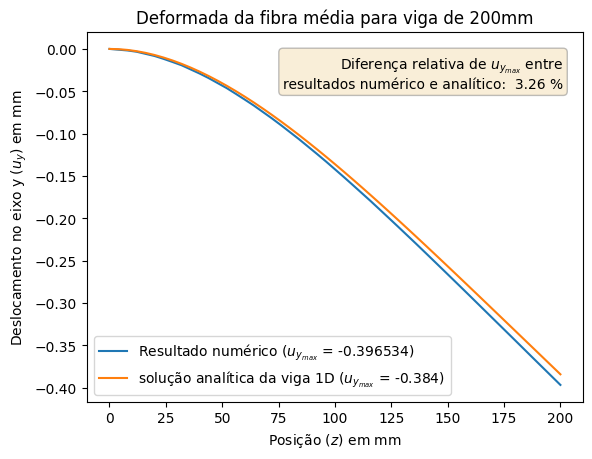

In [6]:
numeric_data = pd.read_csv(os.path.join(numeric_data_directory, 'deformada_fibra_media_200mm_final.csv'), sep = ';')
print(numeric_data.head())

x_analytic_solution_1d = obtain_x_axis_array(200, size = len(numeric_data['x'])) # para 200mm
y_analytic_solution_1d = calculate_analytic_solution(x_analytic_solution_1d)

plot_deformation_graphic(numeric_data, x_analytic_solution_1d, y_analytic_solution_1d)

# Tensões máximas para soluções analíticas de vigas 60, 100 e 200mm

In [7]:
analytic_sigma_zz_max_60mm  = calculate_sigma_zz_max(60)
analytic_sigma_zz_max_100mm = calculate_sigma_zz_max(100)
analytic_sigma_zz_max_200mm = calculate_sigma_zz_max(200)

fea_sigma_zz_max_60mm  =  7.7804E+06 # valor exportado do Abaqus
fea_sigma_zz_max_100mm =  20.6348E+06 # valor exportado do abaqus
fea_sigma_zz_max_200mm =  79.406E+06 # valor exportado do Abaqus
print(f''' 

solução analítica para tensão axial máxima no engaste (z = 0):
      
    -> para viga de 60mm:  {analytic_sigma_zz_max_60mm:e}
    -> para viga de 100mm: {analytic_sigma_zz_max_100mm:e}
    -> para viga de 200mm: {analytic_sigma_zz_max_200mm:e}

Diferença relativa (em percentual) entre solução analítica e simulação por elementos finitos:

    -> 60mm:  {calculate_relative_error(analytic_sigma_zz_max_60mm, fea_sigma_zz_max_60mm):2f} %
    -> 100mm: {calculate_relative_error(analytic_sigma_zz_max_100mm, fea_sigma_zz_max_100mm):2f} %
    -> 200mm: {calculate_relative_error(analytic_sigma_zz_max_200mm, fea_sigma_zz_max_200mm):2f} %
      
''')

 

solução analítica para tensão axial máxima no engaste (z = 0):
      
    -> para viga de 60mm:  8.640000e+06
    -> para viga de 100mm: 2.400000e+07
    -> para viga de 200mm: 9.600000e+07

Diferença relativa (em percentual) entre solução analítica e simulação por elementos finitos:

    -> 60mm:  11.048275 %
    -> 100mm: 16.308372 %
    -> 200mm: 20.897665 %
      

